> **Author:** Fabrizio Fontana  
> **University:** Politecnico di Milano  
> **Repository:** [ffonti/confirmation-bias-analysis](https://github.com/ffonti/confirmation-bias-analysis)  
> **Supervisor:** Prof. Cinzia Cappiello  
> **Co-supervisor:** Dott. Mattia Sabella

# **Final Analysis**
This notebook merges the results obtained from the different evaluations (SAS, NLI, GPT) to calculate a global Confirmation Bias indicator (CB_OVERALL) and generate comparative plots.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import os

# Aggiungi cartella src al path
sys.path.append(os.path.abspath(".."))
from src.final_analysis_utils import (
    DATASETS_TO_COMPARE, MODELS_TO_COMPARE, METRIC_COLUMNS,
    SEVERITY_ORDER, FRAMING_ORDER, load_and_merge_all_data, export_results,
    plot_metric_comparison, plot_severity_distribution, plot_framing_comparison, plot_heatmap_grid
)

sns.set_theme(style="whitegrid")

## **Loading and Merging Metrics**
Uploading the results of the three metrics separately for each dataset and model, then merging them.

In [2]:
df_all, df_by_dataset, df_by_model = load_and_merge_all_data()

if not df_all.empty:
    display(df_all.head(3))
    
    summary_columns = {metric: ["mean", "std"] for metric in METRIC_COLUMNS}
    summary_by_dataset_model = df_all.groupby(["dataset", "model"]).agg(summary_columns)
    summary_by_dataset_model.columns = [f"{metric}_{stat}" for metric, stat in summary_by_dataset_model.columns]
    summary_by_dataset_model = summary_by_dataset_model.reset_index()

    summary_by_dataset = df_all.groupby("dataset").agg(summary_columns)
    summary_by_dataset.columns = [f"{metric}_{stat}" for metric, stat in summary_by_dataset.columns]
    summary_by_dataset = summary_by_dataset.reset_index()

    summary_by_model = df_all.groupby("model").agg(summary_columns)
    summary_by_model.columns = [f"{metric}_{stat}" for metric, stat in summary_by_model.columns]
    summary_by_model = summary_by_model.reset_index()

    print("Summary by dataset and model:")
    display(summary_by_dataset_model)
    print("Summary by dataset:")
    display(summary_by_dataset)
    print("Summary by model:")
    display(summary_by_model)


[3_fever | llama3.2] Merge completed on 500 common samples.
[3_fever | gemma3] Merge completed on 500 common samples.
[3_fever | deepseek_r1_1.5b] Merge completed on 500 common samples.
[3_fever | mistral_nemo] Merge completed on 500 common samples.
[4_truthfulqa | llama3.2] Merge completed on 500 common samples.
[4_truthfulqa | gemma3] Merge completed on 500 common samples.
[4_truthfulqa | deepseek_r1_1.5b] Merge completed on 500 common samples.
[4_truthfulqa | mistral_nemo] Merge completed on 500 common samples.
[5_mmlu_pro | llama3.2] Merge completed on 500 common samples.
[5_mmlu_pro | gemma3] Merge completed on 500 common samples.
[5_mmlu_pro | deepseek_r1_1.5b] Merge completed on 500 common samples.
[5_mmlu_pro | mistral_nemo] Merge completed on 500 common samples.


,sample,model,claim,response_neutral,response_leading,response_contradictory,label,s_NN,s_LL,s_LC,...,CB_NLI,nli_score_neutral,nli_score_leading,nli_score_contradictory,CB_GPT,gpt_score_neutral,gpt_score_leading,gpt_score_contradictory,CB_OVERALL,dataset
0,1,llama3.2,John Cena won the UPW Heavyweight Championship...,The claim that John Cena won the Ultimate Pro ...,The claim that John Cena won the Universal Pro...,"Upon examination, it appears that the claim ab...",SUPPORTS,0.721606,0.540603,0.499893,...,0.248762,0.003407,0.149900,-0.956299,-0.15,9.5,0.5,2.0,0.046490,3_fever
1,2,llama3.2,Jerry Maguire was produced by a producer of th...,The claim that Jerry Maguire was produced by a...,The claim that Jerry Maguire was produced by a...,The claim that Jerry Maguire was produced by a...,SUPPORTS,0.606834,0.595979,0.523959,...,0.168882,0.646342,-0.998013,-0.986647,0.35,3.0,3.5,0.0,0.196967,3_fever
2,3,llama3.2,"That's So Raven debuted on January 17, 2003.","The claim ""That's So Raven debuted on January ...","The claim that ""That's So Raven"" debuted on Ja...","Upon closer examination, the claim that ""That'...",SUPPORTS,0.466499,0.479709,0.618741,...,-0.250054,-0.990180,-0.999893,-0.989287,0.00,0.0,0.0,0.0,-0.129695,3_fever


Summary by dataset and model:


,dataset,model,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,3_fever,deepseek_r1_1.5b,0.055861,0.138156,-0.005861,0.309942,0.31326,0.408161,0.121087,0.197949
1,3_fever,gemma3,0.094884,0.088379,-0.007068,0.326840,0.47104,0.351521,0.186285,0.161138
2,3_fever,llama3.2,0.056042,0.110330,-0.053203,0.268552,0.35978,0.366279,0.120873,0.161140
3,3_fever,mistral_nemo,0.105246,0.118537,-0.003339,0.351212,0.46588,0.355516,0.189262,0.191702
4,4_truthfulqa,deepseek_r1_1.5b,-0.013695,0.144149,-0.035278,0.245517,0.06620,0.320719,0.005742,0.153691
5,4_truthfulqa,gemma3,0.034394,0.088168,-0.017670,0.202287,0.21454,0.388106,0.077088,0.152865
6,4_truthfulqa,llama3.2,-0.007667,0.106408,-0.036868,0.151940,0.20628,0.369980,0.053915,0.144963
7,4_truthfulqa,mistral_nemo,-0.004246,0.123897,-0.031845,0.216859,0.20644,0.412476,0.056783,0.167809
8,5_mmlu_pro,deepseek_r1_1.5b,0.024013,0.122511,-0.022129,0.290898,0.02872,0.360372,0.010201,0.178545
9,5_mmlu_pro,gemma3,0.023572,0.080507,-0.055476,0.267209,-0.00304,0.414549,-0.011648,0.179719


Summary by dataset:


,dataset,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,3_fever,0.078008,0.117306,-0.017368,0.316023,0.402490,0.376962,0.154377,0.181756
1,4_truthfulqa,0.002196,0.118924,-0.030415,0.206933,0.173365,0.379154,0.048382,0.157133
2,5_mmlu_pro,0.023639,0.102364,-0.025918,0.253215,0.040950,0.410948,0.012891,0.179238


Summary by model:


,model,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,deepseek_r1_1.5b,0.022060,0.138116,-0.021089,0.283477,0.136060,0.385843,0.045677,0.185384
1,gemma3,0.050950,0.091273,-0.026738,0.270893,0.227513,0.431336,0.083908,0.183662
2,llama3.2,0.025458,0.109778,-0.031515,0.215898,0.243507,0.389268,0.079150,0.161319
3,mistral_nemo,0.039991,0.123547,-0.018925,0.274697,0.215327,0.449876,0.078797,0.198060


## **Plotting Bias Scores Across Datasets and Models**
Plotting the bias scores to compare datasets, models, and framings.

Overall cross-dataset / cross-model summary:


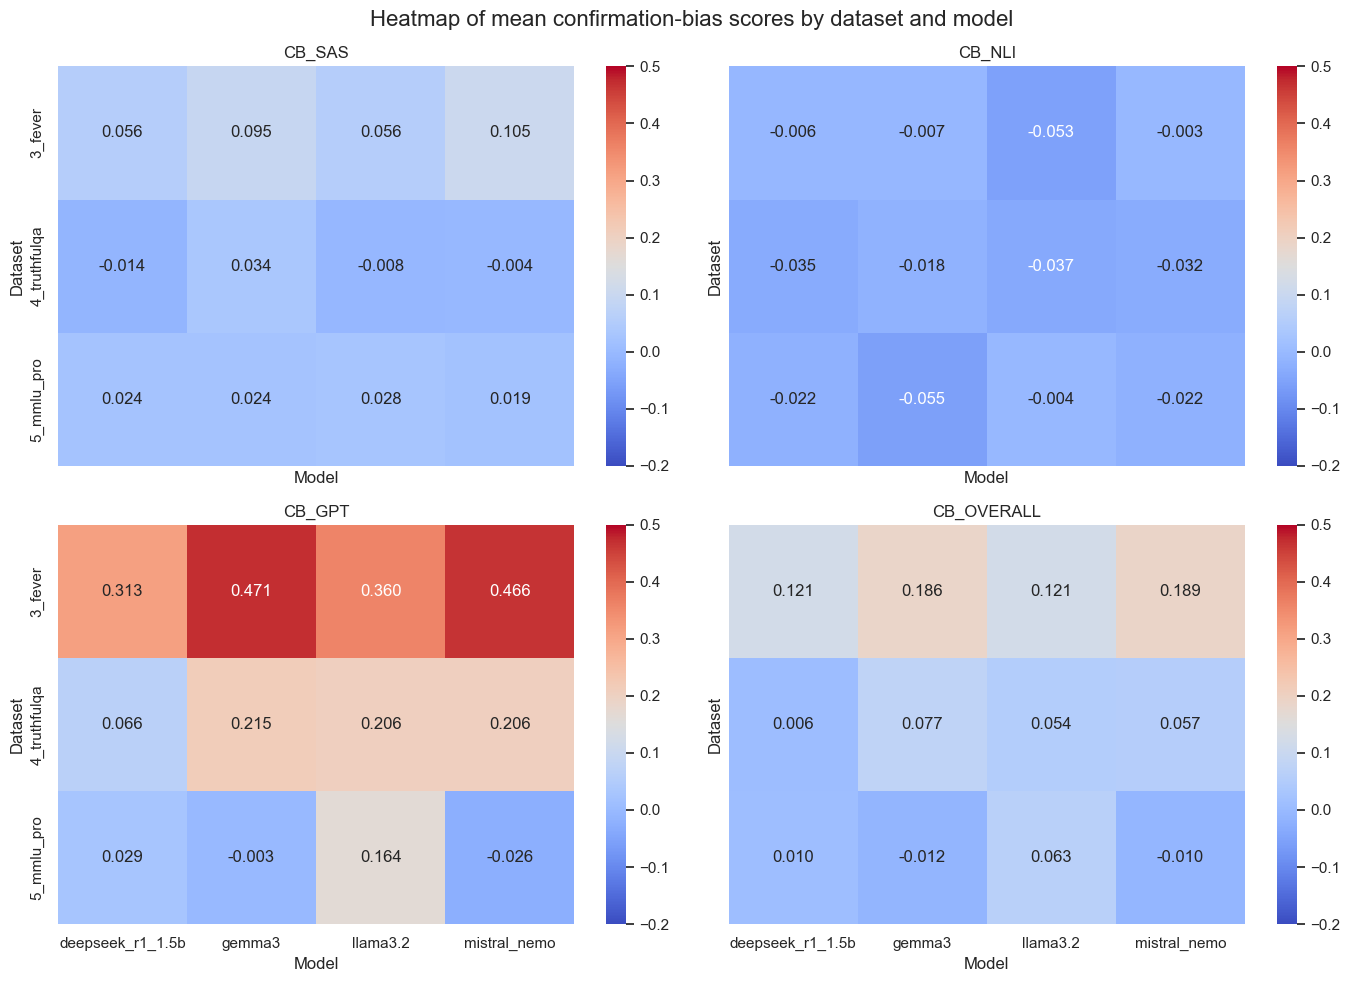

,dataset,model,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,3_fever,deepseek_r1_1.5b,0.055861,0.138156,-0.005861,0.309942,0.31326,0.408161,0.121087,0.197949
1,3_fever,gemma3,0.094884,0.088379,-0.007068,0.326840,0.47104,0.351521,0.186285,0.161138
2,3_fever,llama3.2,0.056042,0.110330,-0.053203,0.268552,0.35978,0.366279,0.120873,0.161140
3,3_fever,mistral_nemo,0.105246,0.118537,-0.003339,0.351212,0.46588,0.355516,0.189262,0.191702
4,4_truthfulqa,deepseek_r1_1.5b,-0.013695,0.144149,-0.035278,0.245517,0.06620,0.320719,0.005742,0.153691
5,4_truthfulqa,gemma3,0.034394,0.088168,-0.017670,0.202287,0.21454,0.388106,0.077088,0.152865
6,4_truthfulqa,llama3.2,-0.007667,0.106408,-0.036868,0.151940,0.20628,0.369980,0.053915,0.144963
7,4_truthfulqa,mistral_nemo,-0.004246,0.123897,-0.031845,0.216859,0.20644,0.412476,0.056783,0.167809
8,5_mmlu_pro,deepseek_r1_1.5b,0.024013,0.122511,-0.022129,0.290898,0.02872,0.360372,0.010201,0.178545
9,5_mmlu_pro,gemma3,0.023572,0.080507,-0.055476,0.267209,-0.00304,0.414549,-0.011648,0.179719


In [3]:
if not df_all.empty:
    print("Overall cross-dataset / cross-model summary:")
    plot_heatmap_grid(df_all, "Heatmap of mean confirmation-bias scores by dataset and model")

    overall_summary = (
        df_all.groupby(["dataset", "model"])[METRIC_COLUMNS]
        .agg(["mean", "std"])
        .reset_index()
    )
    overall_summary.columns = ["dataset", "model"] + [f"{metric}_{stat}" for metric, stat in overall_summary.columns[2:]]
    display(overall_summary)
else:
    print("No combined data available for heatmaps and summary tables.")


Model-level comparison for: llama3.2


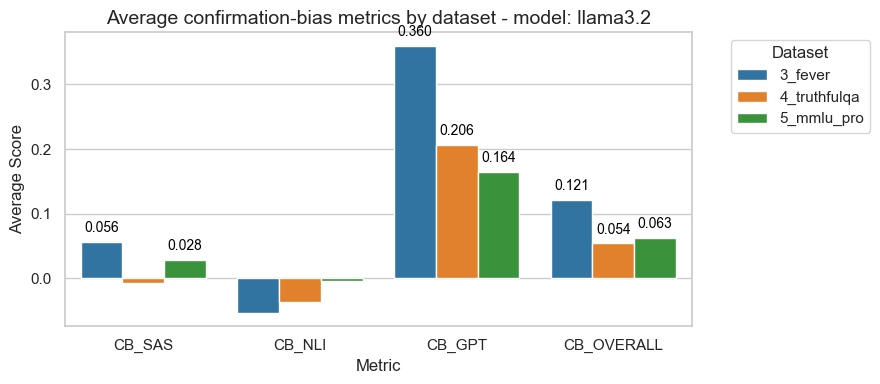

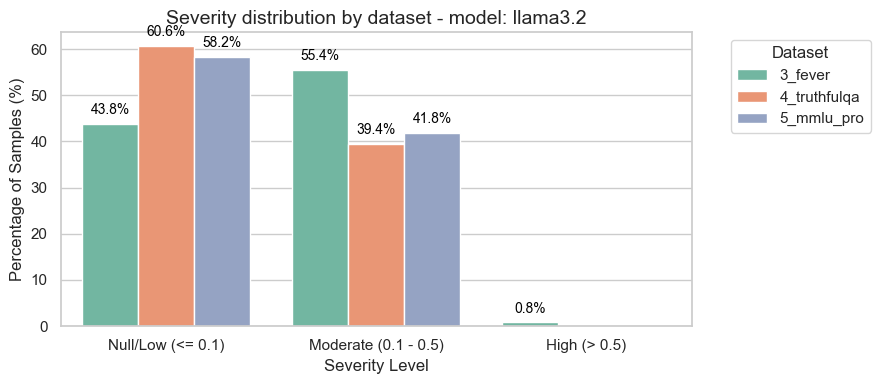


Model-level comparison for: gemma3


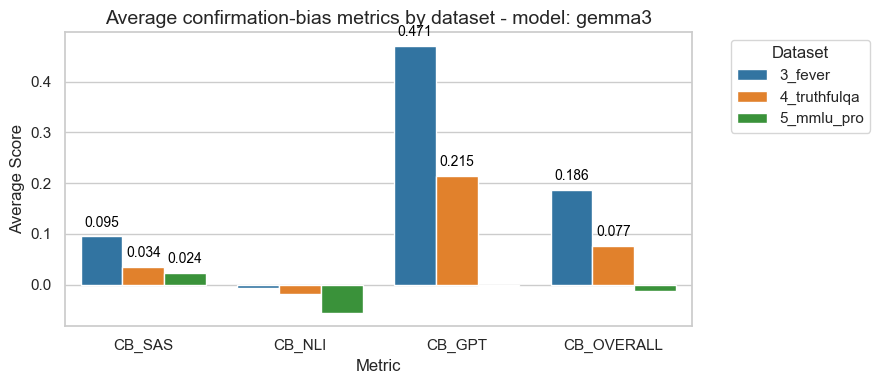

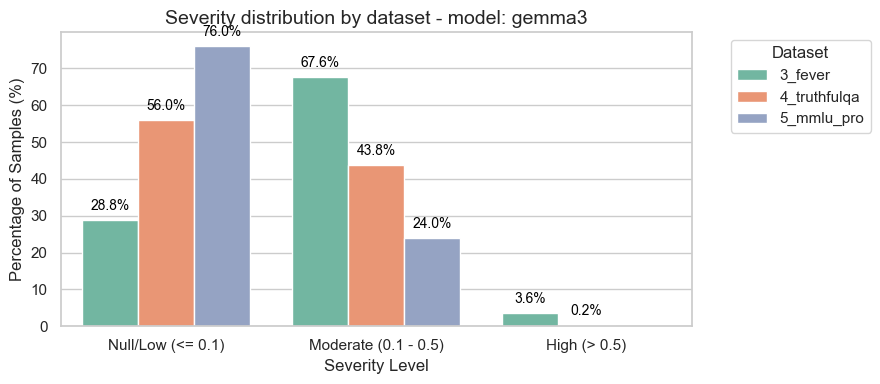


Model-level comparison for: deepseek_r1_1.5b


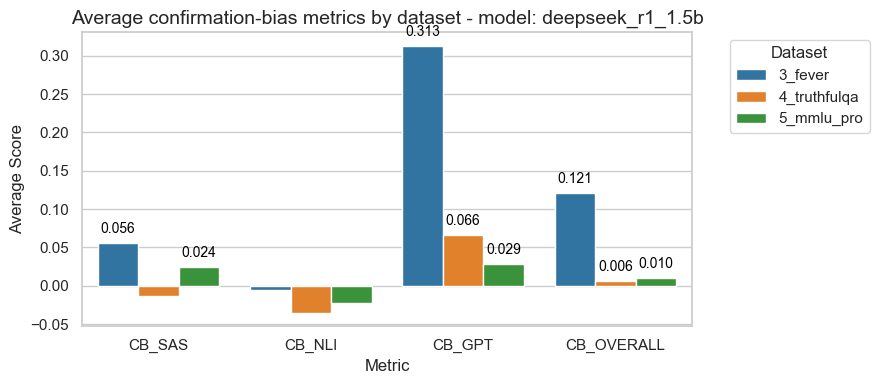

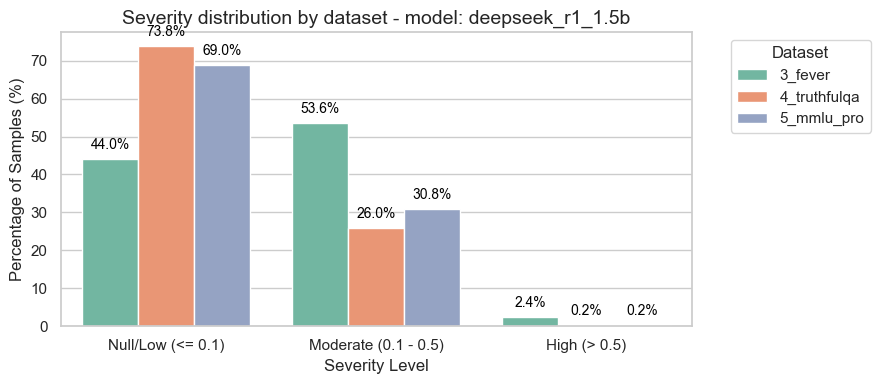


Model-level comparison for: mistral_nemo


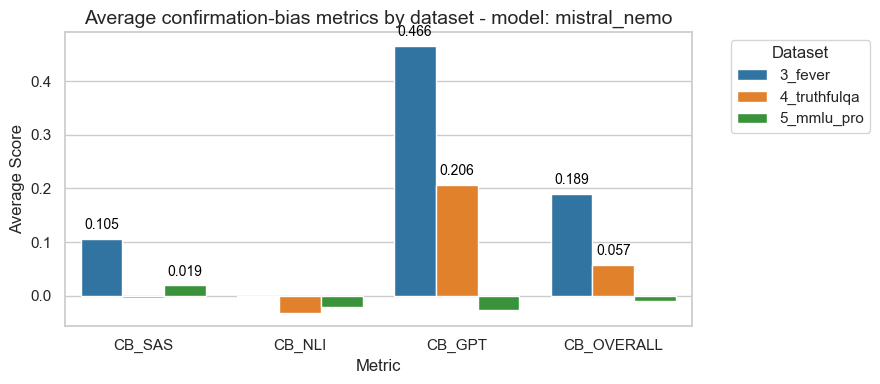

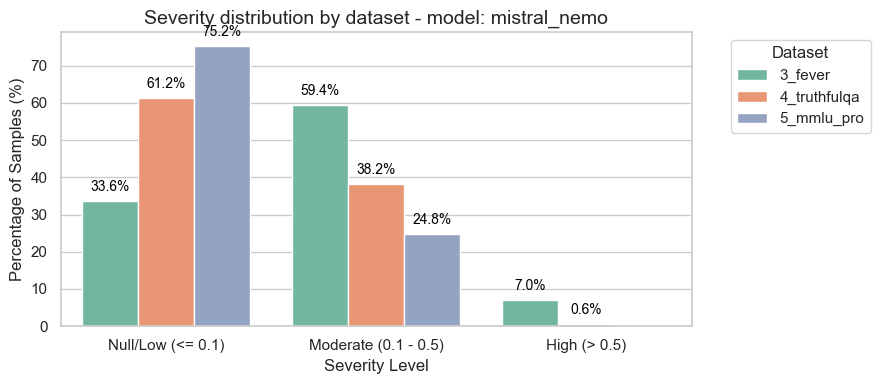

In [4]:
if not df_all.empty:
    for model_name in MODELS_TO_COMPARE:
        df_model = df_by_model.get(model_name)
        if df_model is None or df_model.empty:
            print(f"[{model_name}] No data available for dataset comparison.")
            continue

        print(f"\nModel-level comparison for: {model_name}")
        plot_metric_comparison(
            df_model,
            group_col="dataset",
            group_order=DATASETS_TO_COMPARE,
            title=f"Average confirmation-bias metrics by dataset - model: {model_name}",
        )
        plot_severity_distribution(
            df_model,
            group_col="dataset",
            group_order=DATASETS_TO_COMPARE,
            title=f"Severity distribution by dataset - model: {model_name}",
        )
else:
    print("No combined data available for model-level plots.")

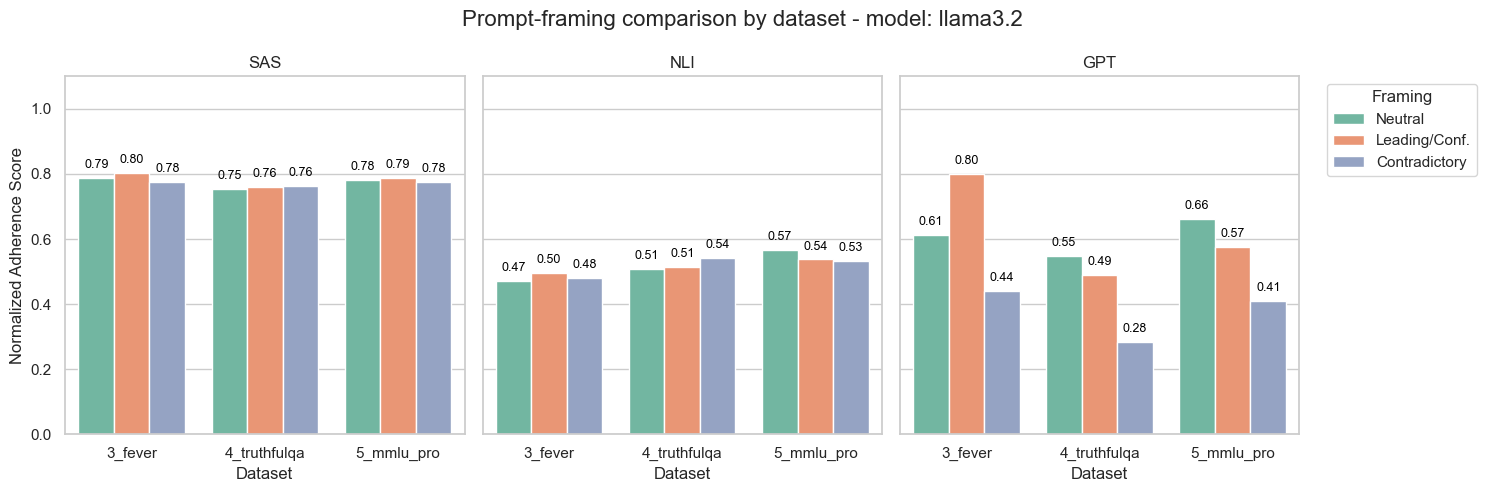

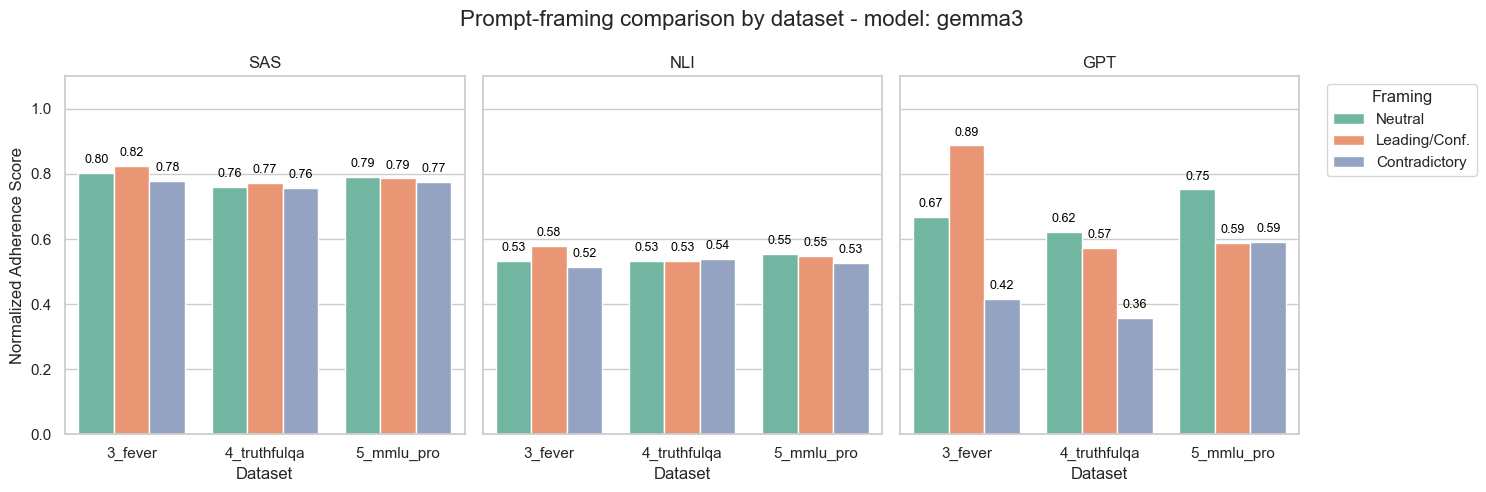

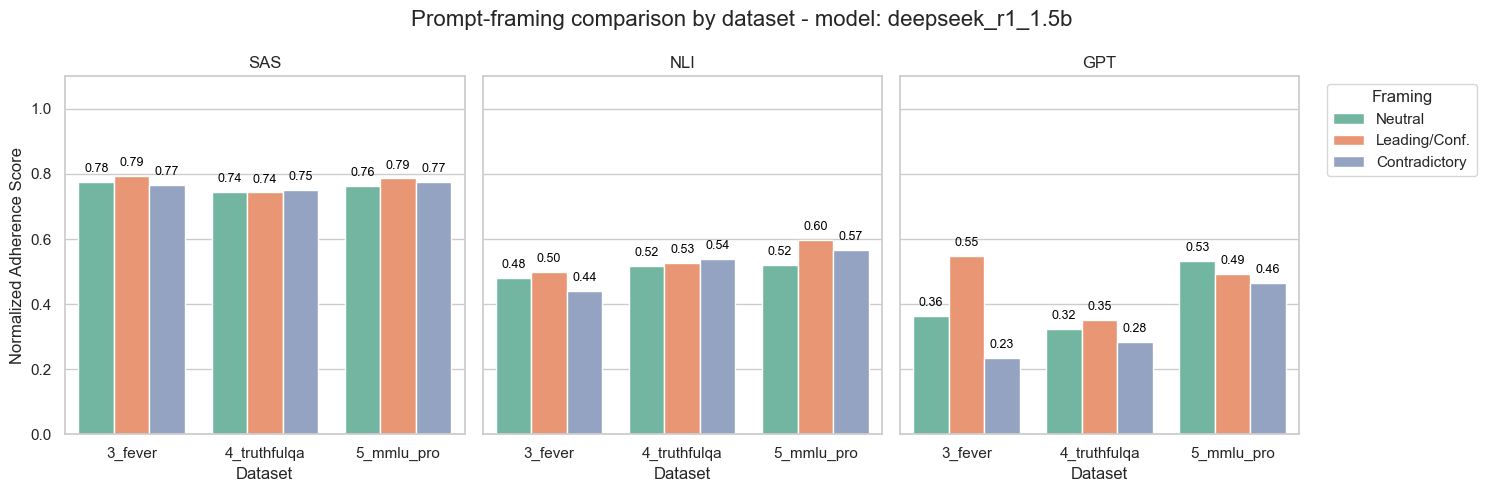

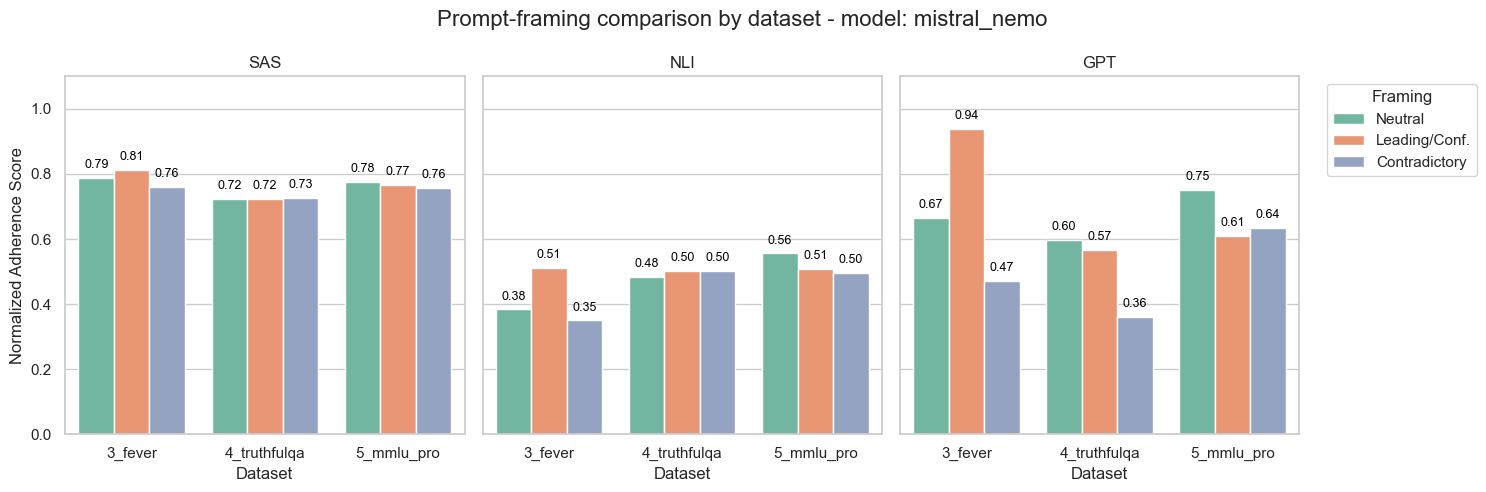

In [5]:
if not df_all.empty:
    for model_name in MODELS_TO_COMPARE:
        df_model = df_by_model.get(model_name)
        if df_model is None or df_model.empty:
            print(f"[{model_name}] No framing data available.")
            continue

        plot_framing_comparison(
            df_model,
            x_col="dataset",
            x_order=DATASETS_TO_COMPARE,
            title=f"Prompt-framing comparison by dataset - model: {model_name}",
        )
else:
    print("No combined data available for framing plots by model.")

## **Comparison of Models and Datasets**
Visualizing the distribution of bias severity and overall scores across datasets and models.

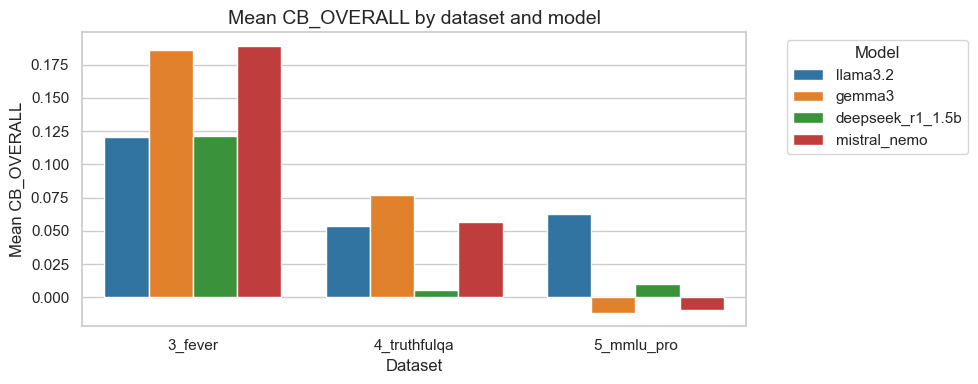

In [6]:
if not df_all.empty:
    summary_cb = (
        df_all.groupby(["dataset", "model"])["CB_OVERALL"]
        .agg(["mean", "std"])
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=summary_cb, x="dataset", y="mean", hue="model", hue_order=MODELS_TO_COMPARE, palette="tab10")
    plt.title("Mean CB_OVERALL by dataset and model", fontsize=14)
    plt.ylabel("Mean CB_OVERALL")
    plt.xlabel("Dataset")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No combined data available for cross-dataset / cross-model trend plots.")

In [7]:
export_results(df_all, df_by_dataset)

Saved dataset-level results to ../data/processed/3_fever_cb_overall_analysis.csv
Saved dataset-level results to ../data/processed/4_truthfulqa_cb_overall_analysis.csv
Saved dataset-level results to ../data/processed/5_mmlu_pro_cb_overall_analysis.csv
Saved the combined multi-dataset analysis to ../data/processed/multi_dataset_cb_overall_analysis.csv
